# t-SNE

### A beautiful map you must not over-read

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | What t-SNE optimises, and why perplexity changes the picture so much. Which features of the plot mean something and which are artefacts. And why you must never use it as a preprocessing step |
| **You should already know** | [PCA](../01-principal-component-analysis/) |
| **Datasets** | UCI Dry Bean, Fashion-MNIST |
| **Runtime** | Three to four minutes on a laptop CPU |
| **Next** | [06-04 UMAP](../04-umap/) |

---

## 1. The idea

[PCA](../01-principal-component-analysis/) is linear. It rotates the axes and
keeps the directions of greatest variance, which means it can only unfold
structure that was already flat. Think of a sheet of paper rolled into a tube.
PCA can turn the tube, but it cannot unroll it, so it flattens the tube and the
two ends of the paper land on top of each other.

t-SNE takes a different goal entirely. It does not try to preserve the data. It
tries to preserve **who is near whom**:

1. In the original space, turn distances into probabilities: for each point, the
   chance it would pick each other point as a neighbour.
2. Place points at random in two dimensions and compute the same probabilities there.
3. Move the points until the two sets of probabilities match.

The word to hold on to is **neighbour**. t-SNE optimises local relationships and
treats everything else as expendable. Section 4 is about what it spends.

One detail matters. In the low-dimensional space t-SNE uses a **Student-t**
distribution with heavy tails rather than a Gaussian. Without it, everything
collapses into one blob, because there is not enough room in two dimensions to
keep moderately distant points apart. The heavy tail gives distant points a
gentle push away, and that push is what opens the gaps you see between clusters.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

from sklearn.preprocessing import StandardScaler

X, y = datasets.dry_bean()
rng = np.random.default_rng(SEED)
subset = rng.choice(len(X), 3000, replace=False)
X_small = StandardScaler().fit_transform(X.values[subset])
y_small = y.values[subset]
varieties = sorted(set(y_small))
print(f"{len(X_small):,} beans sampled from {len(X):,}, {X_small.shape[1]} features")

3,000 beans sampled from 13,611, 16 features


## 2. Against PCA, side by side

PCA   : instant, and the axes mean something (variance directions)
t-SNE : 15.4 s, and the axes mean nothing at all


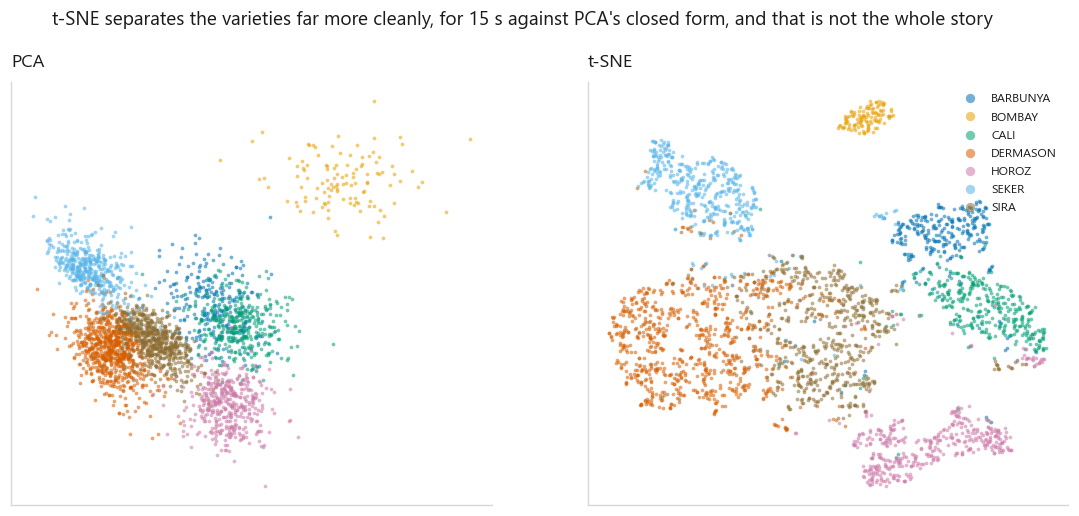

In [2]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pca_points = PCA(n_components=2, random_state=SEED).fit_transform(X_small)

start = time.perf_counter()
tsne_points = TSNE(n_components=2, perplexity=30, random_state=SEED,
                   init="pca").fit_transform(X_small)
tsne_seconds = time.perf_counter() - start

fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.0))
for ax, points, name in [(axes[0], pca_points, "PCA"), (axes[1], tsne_points, "t-SNE")]:
    for i, variety in enumerate(varieties):
        sel = y_small == variety
        ax.scatter(points[sel, 0], points[sel, 1], s=6, alpha=0.55,
                   c=style.PALETTE[i], linewidths=0, label=variety)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    style.title(ax, name)
axes[1].legend(fontsize=8, markerscale=2.5, loc="upper right")
fig.suptitle(f"t-SNE separates the varieties far more cleanly, for "
             f"{tsne_seconds:.0f} s against PCA's closed form, and that is not "
             f"the whole story",
             x=0.5, y=1.01, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-vs-pca.png")

print(f"PCA   : instant, and the axes mean something (variance directions)")
print(f"t-SNE : {tsne_seconds:.1f} s, and the axes mean nothing at all")

The t-SNE picture is obviously prettier, and prettier is exactly the danger. The
next section shows how much the picture moves when you turn one dial, and section
4 sets out the short list of things it is entitled to say.

## 3. Perplexity changes everything

`perplexity` is roughly "how many neighbours should each point care about". It is
the main dial, and the same data can look like a completely different dataset
depending on where it is set.

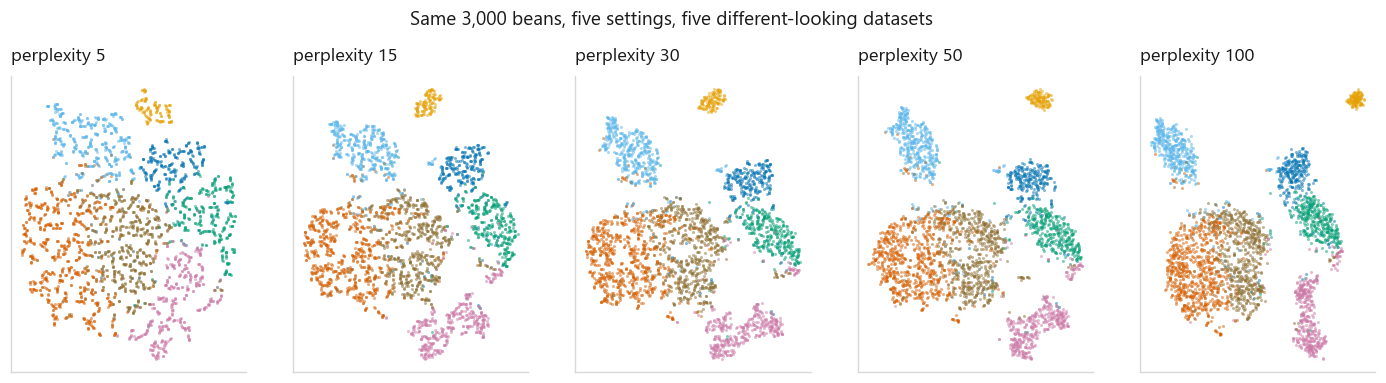

In [3]:
perplexities = [5, 15, 30, 50, 100]
fig, axes = plt.subplots(1, 5, figsize=(16.0, 3.5))

for ax, perplexity in zip(axes, perplexities):
    points = TSNE(n_components=2, perplexity=perplexity, random_state=SEED,
                  init="pca").fit_transform(X_small)
    for i, variety in enumerate(varieties):
        sel = y_small == variety
        ax.scatter(points[sel, 0], points[sel, 1], s=4, alpha=0.5,
                   c=style.PALETTE[i], linewidths=0)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    style.title(ax, f"perplexity {perplexity}")

fig.suptitle("Same 3,000 beans, five settings, five different-looking datasets",
             x=0.5, y=1.05, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-perplexity.png")

Low perplexity fragments the data into many small islands that do not correspond
to anything real. High perplexity merges genuinely separate groups. Neither
extreme is *wrong* (they are answering different questions about what counts as
a neighbourhood), but a reader shown only one of these would draw a different
conclusion each time.

**Always look at several perplexities before believing any of them.**

## 4. Three things the plot cannot tell you

This is the part that matters, and it is where most published t-SNE figures go
wrong.

cluster sizes (radius):
  cluster 0: real   0.58   t-SNE  12.91
  cluster 1: real   4.14   t-SNE  14.37
  cluster 2: real   0.57   t-SNE  11.89

distances between cluster centres:
  0 to 1: real   7.81   t-SNE  44.46
  0 to 2: real  40.06   t-SNE  94.04

real ratio of those two gaps : 5.13
t-SNE ratio                  : 2.12


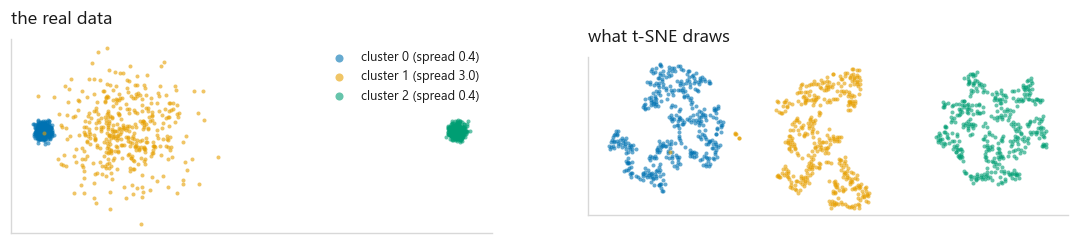

In [4]:
# Build data where we KNOW the answer: three blobs of deliberately different
# spread, placed at deliberately different distances.
centres = np.array([[0, 0], [8, 0], [40, 0]], dtype=float)
spreads = [0.4, 3.0, 0.4]
sizes = [400, 400, 400]

truth_points, truth_labels = [], []
for i, (centre, spread, n) in enumerate(zip(centres, spreads, sizes)):
    truth_points.append(rng.normal(centre, spread, (n, 2)))
    truth_labels += [i] * n
truth_points = np.vstack(truth_points)
truth_labels = np.array(truth_labels)

embedded = TSNE(n_components=2, perplexity=30, random_state=SEED,
                init="pca").fit_transform(truth_points)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4))
for ax, points, name in [(axes[0], truth_points, "the real data"),
                         (axes[1], embedded, "what t-SNE draws")]:
    for i in range(3):
        sel = truth_labels == i
        ax.scatter(points[sel, 0], points[sel, 1], s=7, alpha=0.6,
                   c=style.PALETTE[i], linewidths=0, label=f"cluster {i} (spread {spreads[i]})")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_aspect("equal")
    style.title(ax, name)
axes[0].legend(fontsize=8.5, markerscale=2)
style.save(fig, FIG / "fig-03-what-it-distorts.png")


def spread_of(points, labels, i):
    sel = labels == i
    return float(np.sqrt(((points[sel] - points[sel].mean(axis=0)) ** 2).sum(axis=1).mean()))


def gap(points, labels, a, b):
    return float(np.linalg.norm(points[labels == a].mean(axis=0) - points[labels == b].mean(axis=0)))


print("cluster sizes (radius):")
for i in range(3):
    print(f"  cluster {i}: real {spread_of(truth_points, truth_labels, i):6.2f}   "
          f"t-SNE {spread_of(embedded, truth_labels, i):6.2f}")
print("\ndistances between cluster centres:")
print(f"  0 to 1: real {gap(truth_points, truth_labels, 0, 1):6.2f}   "
      f"t-SNE {gap(embedded, truth_labels, 0, 1):6.2f}")
print(f"  0 to 2: real {gap(truth_points, truth_labels, 0, 2):6.2f}   "
      f"t-SNE {gap(embedded, truth_labels, 0, 2):6.2f}")
print(f"\nreal ratio of those two gaps : {gap(truth_points, truth_labels, 0, 2) / gap(truth_points, truth_labels, 0, 1):.2f}")
print(f"t-SNE ratio                  : {gap(embedded, truth_labels, 0, 2) / gap(embedded, truth_labels, 0, 1):.2f}")

The three clusters were built with cluster 1 having **seven times** the spread of
the others, and cluster 2 placed **five times** further from cluster 0 than
cluster 1 was. Look at what came out of the embedding.

**Cluster size means nothing.** t-SNE expands sparse clusters and compresses dense
ones, because it is equalising local neighbour densities. A big blob on a t-SNE
plot is not a more variable group.

**Distance between clusters means nothing.** The 5-to-1 ratio in the real data
does not survive. Two clusters far apart on the plot are not necessarily more
different than two that are close.

**Empty space means nothing.** Gaps are produced by the heavy-tailed repulsion,
not measured from the data.

What the plot *is* entitled to say: **these points were near each other in the
original space.** Local neighbourhood, and nothing more.

## 5. Never put it in a pipeline

There is a practical consequence that catches people out. t-SNE has no
`transform` method: it cannot embed a new point without refitting everything.
The embedding is an optimisation over one fixed set of points, not a function.

does TSNE have a .transform method? False
does PCA  have a .transform method? True


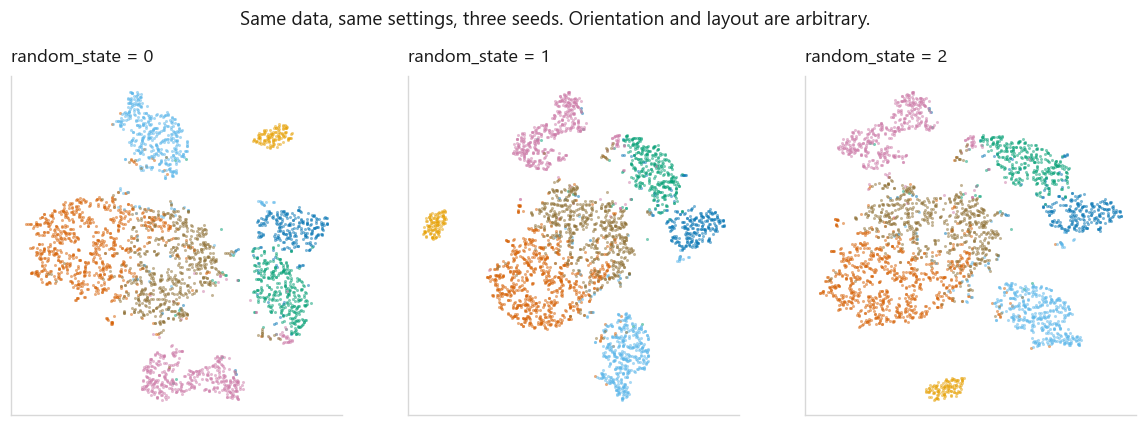

In [5]:
model = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca")
print("does TSNE have a .transform method?", hasattr(model, "transform"))
print("does PCA  have a .transform method?", hasattr(PCA(n_components=2), "transform"))

# Different seeds, same data, same settings.
seeds = [0, 1, 2]
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.0))
for ax, seed in zip(axes, seeds):
    points = TSNE(n_components=2, perplexity=30, random_state=seed,
                  init="random").fit_transform(X_small)
    for i, variety in enumerate(varieties):
        sel = y_small == variety
        ax.scatter(points[sel, 0], points[sel, 1], s=4, alpha=0.5,
                   c=style.PALETTE[i], linewidths=0)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    style.title(ax, f"random_state = {seed}")
fig.suptitle("Same data, same settings, three seeds. Orientation and layout are arbitrary.",
             x=0.5, y=1.03, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-04-seeds.png")

Because there is no `transform`, **t-SNE cannot be a preprocessing step**. Putting
it before a classifier is leakage rather than merely awkward: to embed your test set
you would have to refit on train and test together, which lets test points
influence the representation.

Use PCA when you need dimensionality reduction inside a model. Use t-SNE when you
need a picture for a human.

## Cheat sheet

| | |
|---|---|
| **Use it when** | You want to *look* at high-dimensional data and see whether groups exist |
| **Never** | As a preprocessing step for a model. It has no `transform`, and faking one leaks |
| **Scaling needed** | Yes. It is distance-based |
| **Main dials** | `perplexity` (5 to 50, try several), `init="pca"` for stability, `learning_rate="auto"` |
| **Cost** | Roughly $O(n \log n)$ with Barnes-Hut, but slow in practice. Subsample above ~10,000 points |
| **Read from it** | Which points are neighbours. Nothing else |
| **Do not read** | Cluster sizes, between-cluster distances, or the meaning of empty space |
| **Next** | [UMAP](../04-umap/), which is faster, preserves more global structure, and does offer `transform` |

## What to remember

1. t-SNE matches neighbour probabilities and never looks at a distance again
   once it has them. Everything else here follows from that one fact.
2. Cluster size, cluster distance and empty space are artefacts, and the reason
   is the objective rather than the implementation. Rescale a cluster or slide
   it across the page and the neighbour relationships do not change, so nothing
   in the loss objects.
3. Perplexity changes the picture enough to change your conclusion. Look at
   three settings before believing any of them.
4. No `transform`, so it never belongs in a pipeline. Faking one by fitting on
   train and test together is leakage, not a workaround.
5. Treat the output as a hypothesis and test it with something that has a
   held-out score. A t-SNE plot is where a question starts, not where it ends.

Where this sits in Part 6. [06-01 PCA](../01-principal-component-analysis/) is the
opposite trade in every respect: ugly picture, meaningful axes, exact inverse,
safe in a pipeline, and it measured no accuracy gain from reducing at all. This
chapter buys a far better picture by giving up every one of those properties.
[06-04 UMAP](../04-umap/) buys some of them back, and its chapter measures how
much rather than repeating the claim.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [06-04 UMAP](../04-umap/) · Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#tSNE` `#DimensionalityReduction` `#DataVisualization`
`#UnsupervisedLearning` `#Python` `#ScikitLearn` `#MLTutorial` `#Manifold`